###
<h1><strong>Task 3: Natural Language Processing (NLP) - Sentiment Analysis</strong></h1>
<p><strong>Description:</strong> Perform sentiment analysis on textual data (e.g., customer reviews, social media comments) to classify text as positive, negative, or neutral.</p>

<h3><strong> Objectives:</strong></h3> 
<ul>
    <li>Preprocess text data (tokenization, removing stopwords, and stemming/lemmatization).</li>
    <li>Use nltk or TextBlob for sentiment analysis.</li>
    <li>Visualize the sentiment distribution and word frequencies using word clouds</li>
</ul>
<p>Tools: Python, nltk, TextBlob, pandas, matplotlib</p>

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/codveda_datanalysis
Cleaned files : 5


<h4>The dataset: Sentiment</h4>
<p>
    <h4><strong><li>Data preprocessing</li></strong></h4>
</p>

In [2]:
sent = pd.read_csv(CLEAN_DIR / "c_sentiment.csv")
sent.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,Traffic was terrible this morning.,negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


### Lexical and morphological analysis

Lexical and Morphological Analysis are the initial phases of NLP that help computers understand words, their structure and their grammatical roles

In [4]:
import os
import nltk

nltk_data_dir = Path.home() / "nltk_data"
nltk_data_dir.mkdir(exist_ok=True)
os.environ["NLTK_DATA"] = str(nltk_data_dir)
if str(nltk_data_dir) not in nltk.data.path:
    nltk.data.path.append(str(nltk_data_dir))

# Download the resources used by this notebook.
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True, download_dir=str(nltk_data_dir))

# Keep the original tokens for semantic analysis and create a separate cleaned version.
def tokenize_text(text):
    try:
        return nltk.word_tokenize(text)
    except LookupError:
        nltk.download("punkt", quiet=True, download_dir=str(nltk_data_dir))
        nltk.download("punkt_tab", quiet=True, download_dir=str(nltk_data_dir))
        return nltk.word_tokenize(text)

sent["tokenized_raw"] = sent["Text"].fillna("").astype(str).apply(tokenize_text)

stop_words = set(nltk.corpus.stopwords.words("english"))
sent["tokenized"] = sent["tokenized_raw"].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stop_words]
)

# Stemming and lemmatization support the word-frequency analysis.
stemmer = nltk.stem.PorterStemmer()
sent["stemmed"] = sent["tokenized"].apply(
    lambda tokens: [stemmer.stem(word.lower()) for word in tokens if word.isalpha()]
)

lemmatizer = nltk.stem.WordNetLemmatizer()
sent["lemmatized"] = sent["tokenized"].apply(
    lambda tokens: [lemmatizer.lemmatize(word.lower(), pos="n") for word in tokens if word.isalpha()]
)

sent[["Text", "tokenized_raw", "tokenized", "stemmed", "lemmatized"]].head()

,Text,tokenized_raw,tokenized,stemmed,lemmatized
0,Enjoying a beautiful day at the park!,"[Enjoying, a, beautiful, day, at, the, park, !]","[Enjoying, beautiful, day, park, !]","[enjoy, beauti, day, park]","[enjoying, beautiful, day, park]"
1,Traffic was terrible this morning.,"[Traffic, was, terrible, this, morning, .]","[Traffic, terrible, morning, .]","[traffic, terribl, morn]","[traffic, terrible, morning]"
2,Just finished an amazing workout! 💪,"[Just, finished, an, amazing, workout, !, 💪]","[finished, amazing, workout, !, 💪]","[finish, amaz, workout]","[finished, amazing, workout]"
3,Excited about the upcoming weekend getaway!,"[Excited, about, the, upcoming, weekend, getaw...","[Excited, upcoming, weekend, getaway, !]","[excit, upcom, weekend, getaway]","[excited, upcoming, weekend, getaway]"
4,Trying out a new recipe for dinner tonight.,"[Trying, out, a, new, recipe, for, dinner, ton...","[Trying, new, recipe, dinner, tonight, .]","[tri, new, recip, dinner, tonight]","[trying, new, recipe, dinner, tonight]"


### Semantic Analysis
Semantic Analysis focuses on understanding the meaning of words and sentences. It ensures that text is not only grammatically correct but also logically meaningful and contextually appropriate.

In [5]:
import nltk
from nltk.wsd import lesk

# NER and WSD require the original token sequence, including stopwords and context.
for resource in [
    "maxent_ne_chunker",
    "maxent_ne_chunker_tab",
    "words",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "wordnet",
]:
    nltk.download(resource, quiet=True, download_dir=str(nltk_data_dir))

def extract_entities(tokens):
    tagged = nltk.pos_tag(tokens)
    tree = nltk.ne_chunk(tagged, binary=False)

    entities = []
    for node in tree:
        if hasattr(node, "label"):
            entity = " ".join(word for word, _ in node.leaves())
            entities.append((entity, node.label()))

    return entities

sent["named_entities"] = sent["tokenized_raw"].apply(extract_entities)

# Word Sense Disambiguation uses the original words and their sentence context.
def disambiguate_words(tokens):
    context = [word.lower() for word in tokens if word.isalpha()]
    senses = {}

    for word in context:
        sense = lesk(context, word)
        if sense:
            senses[word] = sense.definition()

    return senses

sent["word_senses"] = sent["tokenized_raw"].apply(disambiguate_words)

sent[["Text", "named_entities", "word_senses"]].head()

,Text,named_entities,word_senses
0,Enjoying a beautiful day at the park!,[],{'enjoying': 'derive or receive pleasure from;...
1,Traffic was terrible this morning.,"[(Traffic, PERSON)]",{'traffic': 'the aggregation of things (pedest...
2,Just finished an amazing workout! 💪,[],{'just': 'used especially of what is legally o...
3,Excited about the upcoming weekend getaway!,[],"{'excited': 'stir the feelings, emotions, or p..."
4,Trying out a new recipe for dinner tonight.,[],"{'trying': 'put to the test, as for its qualit..."


### Sentiment Analysis

VADER analyzes the original `Text` column rather than the stemmed or lemmatized tokens. This is intentional because punctuation, capitalization, emojis, and word order can carry sentiment. The cleaned tokens are used for lexical analysis and word-frequency visualization, while VADER provides the sentiment score.

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

# We keep the original text for VADER so punctuation, capitalization, emojis,
# and word order remain available to the sentiment model.
nltk.download("vader_lexicon", quiet=True, download_dir=str(nltk_data_dir))
sia = SentimentIntensityAnalyzer()

sent["nltk_scores"] = sent["Text"].fillna("").astype(str).apply(
    sia.polarity_scores
)


def classify_sentiment(scores):
    compound = scores["compound"]
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"


sent["nltk_sentiment"] = sent["nltk_scores"].apply(classify_sentiment)

sent[["Text", "Sentiment", "nltk_scores", "nltk_sentiment"]].head(10)

,Text,Sentiment,nltk_scores,nltk_sentiment
0,Enjoying a beautiful day at the park!,positive,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",positive
1,Traffic was terrible this morning.,negative,"{'neg': 0.437, 'neu': 0.563, 'pos': 0.0, 'comp...",negative
2,Just finished an amazing workout! 💪,positive,"{'neg': 0.0, 'neu': 0.494, 'pos': 0.506, 'comp...",positive
3,Excited about the upcoming weekend getaway!,positive,"{'neg': 0.0, 'neu': 0.65, 'pos': 0.35, 'compou...",positive
4,Trying out a new recipe for dinner tonight.,neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",neutral
5,Feeling grateful for the little things in life.,positive,"{'neg': 0.0, 'neu': 0.571, 'pos': 0.429, 'comp...",positive
6,Rainy days call for cozy blankets and hot cocoa.,positive,"{'neg': 0.14, 'neu': 0.86, 'pos': 0.0, 'compou...",negative
7,The new movie release is a must-watch!,positive,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",neutral
8,Political discussions heating up on the timeline.,negative,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",neutral
9,Missing summer vibes and beach days.,neutral,"{'neg': 0.306, 'neu': 0.694, 'pos': 0.0, 'comp...",negative


### Visualization of the sentiment distribution

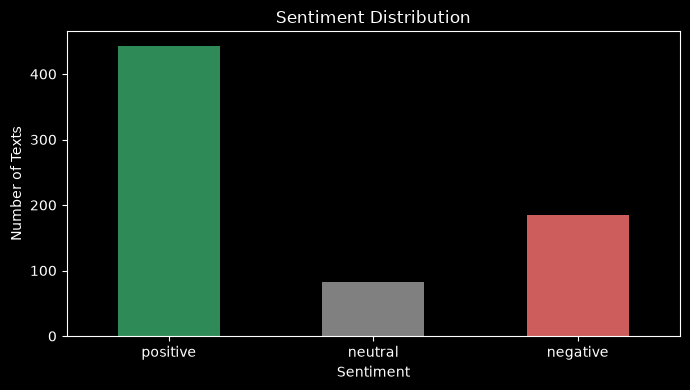

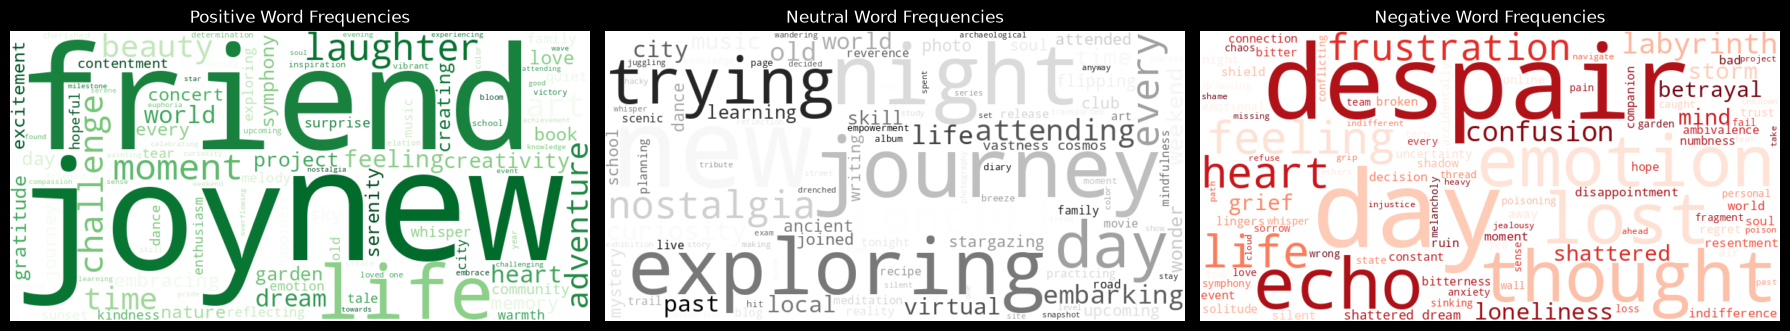

In [11]:
from wordcloud import WordCloud

# Sentiment distribution
plt.figure(figsize=(7, 4))
sent["nltk_sentiment"].value_counts().reindex(
    ["positive", "neutral", "negative"], fill_value=0
).plot(kind="bar", color=["seagreen", "gray", "indianred"])

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Prepare cleaned text for word clouds
def words_for_sentiment(label):
    words = []
    for tokens in sent.loc[sent["nltk_sentiment"] == label, "lemmatized"]:
        words.extend(
            word for word in tokens
            if word.isalpha() and word.lower() not in stop_words
        )
    return " ".join(words)

# Word clouds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {
    "positive": "Greens",
    "neutral": "Greys",
    "negative": "Reds",
}

for ax, label in zip(axes, ["positive", "neutral", "negative"]):
    text = words_for_sentiment(label)

    if text.strip():
        cloud = WordCloud(
            width=800,
            height=400,
            background_color="white",
            colormap=colors[label],
            max_words=100,
        ).generate(text)

        ax.imshow(cloud, interpolation="bilinear")
    else:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")

    ax.set_title(f"{label.capitalize()} Word Frequencies")
    ax.axis("off")

plt.tight_layout()
plt.show()